# Matrix Operations สำหรับ Machine Learning — เรียนด้วย NumPy ทีละขั้น

**ระดับ:** ปานกลาง • **เวลาประมาณ:** 75–100 นาที แบ่งเรียนได้ 2–3 รอบ • **ภาษา:** ไทย พร้อมศัพท์อังกฤษที่ใช้จริง

บทเรียนนี้ใช้ตัวอย่าง โค้ด และภาพที่สร้างขึ้นใหม่ทั้งหมด ต่อยอดจาก `01_vectors_and_matrices.ipynb`
โดยเจาะลึกการดำเนินการกับเมทริกซ์ที่ยังไม่ได้พูดถึง: determinant, inverse, การแก้ระบบสมการเชิงเส้น,
trace และ matrix norm — เป็นพื้นฐานก่อนเข้าเรื่อง eigenvalues/SVD ใน `03_eigenvalues_and_svd.ipynb`

**ก่อนเริ่ม:** ควรผ่าน `01_vectors_and_matrices.ipynb` มาก่อน (คุ้นเคยกับ shape, matrix multiplication,
transpose) เลือก kernel `.venv` ของโครงการ แล้วใช้ **Restart Kernel → Run All**
โค้ดใช้เฉพาะแพ็กเกจที่มีในโครงการ ไม่ต้องดาวน์โหลดข้อมูล รันตามลำดับเพราะเซลล์ถัดไปใช้ตัวแปรจากเซลล์ก่อนหน้า

เมื่อเรียนจบ คุณควรอธิบายได้ว่า:
1. determinant บอกอะไร และทำไม $\det(A)=0$ จึงหมายถึงเมทริกซ์ไม่มี inverse
2. inverse คืออะไร และหาได้อย่างไรทั้งด้วยมือและด้วย NumPy
3. ทำไม Gaussian elimination ต้องมี partial pivoting และทำไมไม่ควรแก้สมการด้วยการคำนวณ inverse ตรงๆ
4. trace คืออะไร และสัมพันธ์กับ eigenvalue อย่างไร
5. Frobenius norm และ spectral norm ต่างกันอย่างไร
6. ทำไม normal equation ($X^\top X\theta = X^\top y$) อาจมีปัญหาเชิงตัวเลขมากกว่า `np.linalg.lstsq`

**เส้นทาง:** ส่วน 1–4 determinant/inverse → ส่วน 5–6 แก้ระบบสมการ → ส่วน 7–8 trace/norm →
ส่วน 9 mini-project → ส่วน 10–11 สรุปและแบบฝึกหัด

## 1. เตรียมเครื่องมือ

ใช้ `numpy.linalg` สำหรับ determinant, inverse, solve และ norm กำหนด seed เพื่อให้ข้อมูลสุ่มทำซ้ำได้
ชื่อในโค้ดใช้ภาษาอังกฤษเพื่ออ่านเอกสารต่อได้ง่าย คำอธิบายและคำถามเป็นภาษาไทย

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

SEED = 42
np.set_printoptions(precision=3, suppress=True)
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
thai_font = next(
    (
        name
        for name in ["Noto Sans Thai", "Tahoma", "Thonburi", "Sukhumvit Set"]
        if name in available_fonts
    ),
    None,
)
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11, "axes.unicode_minus": False})
if thai_font:
    plt.rcParams["font.family"] = thai_font


def label(thai, english):
    return thai if thai_font else english


print("NumPy:", np.__version__)
print("ฟอนต์สำหรับกราฟ:", thai_font or "English fallback")

NumPy: 2.5.3
ฟอนต์สำหรับกราฟ: Tahoma


## 2. Determinant คืออะไร

สำหรับเมทริกซ์ $2\times 2$: $\det\begin{pmatrix}a & b\\ c & d\end{pmatrix} = ad-bc$
ความหมายเชิงเรขาคณิต: $|\det(A)|$ คือ **อัตราส่วนพื้นที่ที่เปลี่ยนไป** เมื่อ $A$ แปลงรูปสี่เหลี่ยมจัตุรัสหน่วย
ถ้า $\det(A)=0$ แสดงว่า $A$ บีบพื้นที่ให้เหลือเส้นตรงหรือจุด (**เมทริกซ์ singular** ไม่มี inverse)
ถ้า $\det(A)<0$ การแปลงมีการสะท้อน (พลิกทิศทาง) ด้วย

อ้างอิง: [Wikipedia — Determinant](https://en.wikipedia.org/wiki/Determinant)

det (มือ): 10.0 ; det (NumPy): 10.000000000000002
พื้นที่หลังแปลง: 10.0 ; |det(A)|: 10.000000000000002


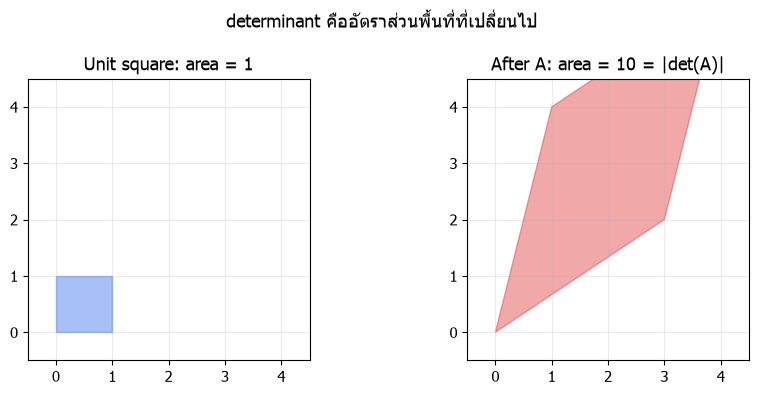

In [2]:
A_det = np.array([[3.0, 1.0], [2.0, 4.0]])
det_manual = A_det[0, 0] * A_det[1, 1] - A_det[0, 1] * A_det[1, 0]
det_numpy = np.linalg.det(A_det)
print("det (มือ):", det_manual, "; det (NumPy):", det_numpy)
np.testing.assert_allclose(det_manual, det_numpy)

# พื้นที่ของรูปสี่เหลี่ยมจัตุรัสหน่วยหลังแปลงด้วย A ควรเท่ากับ |det(A)|
unit_square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]], dtype=float)
transformed_square = unit_square @ A_det.T
x, y = transformed_square[:, 0], transformed_square[:, 1]
area = 0.5 * abs(np.sum(x[:-1] * y[1:] - x[1:] * y[:-1]))  # shoelace formula
print("พื้นที่หลังแปลง:", area, "; |det(A)|:", abs(det_numpy))
np.testing.assert_allclose(area, abs(det_numpy))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].fill(unit_square[:, 0], unit_square[:, 1], alpha=0.4, color="#2563eb")
axes[0].set_title("Unit square: area = 1")
axes[1].fill(transformed_square[:, 0], transformed_square[:, 1], alpha=0.4, color="#dc2626")
axes[1].set_title(f"After A: area = {area:g} = |det(A)|")
for ax in axes:
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(-0.5, 4.5)
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
fig.suptitle(label("determinant คืออัตราส่วนพื้นที่ที่เปลี่ยนไป", "Determinant is the area scale factor"))
plt.tight_layout()
plt.show()

## 3. คุณสมบัติของ Determinant

Determinant ของเมทริกซ์ใหญ่ (เช่น $n\times n$) คำนวณด้วย cofactor expansion แต่ในทางปฏิบัติ
`np.linalg.det` ใช้ LU decomposition ซึ่งเร็วกว่ามาก คุณสมบัติสำคัญที่ใช้บ่อย:

$$\det(AB)=\det(A)\det(B), \qquad \det(A^\top)=\det(A), \qquad \det(cA)=c^n\det(A)$$

และที่สำคัญที่สุดสำหรับบทเรียนนี้: $\det(A)=0 \iff A$ **เป็น singular** (ไม่มี inverse,
คอลัมน์/แถวเป็นอิสระเชิงเส้นไม่ครบ)

In [3]:
rng = np.random.default_rng(SEED)
B_det = rng.normal(size=(3, 3))
C_det = rng.normal(size=(3, 3))
np.testing.assert_allclose(
    np.linalg.det(B_det @ C_det), np.linalg.det(B_det) * np.linalg.det(C_det), atol=1e-8
)
np.testing.assert_allclose(np.linalg.det(B_det.T), np.linalg.det(B_det), atol=1e-8)
np.testing.assert_allclose(np.linalg.det(2 * B_det), (2**3) * np.linalg.det(B_det), atol=1e-6)
print("ตรวจคุณสมบัติ det(AB)=det(A)det(B), det(Aᵀ)=det(A), det(cA)=cⁿdet(A) ผ่านทั้งหมด")

singular = np.array([[1.0, 2.0], [2.0, 4.0]])  # แถวที่สองเป็น 2 เท่าของแถวแรก
print("แถวที่สองเป็น 2 เท่าของแถวแรก → det:", np.linalg.det(singular))
assert abs(np.linalg.det(singular)) < 1e-9
print("matrix rank:", np.linalg.matrix_rank(singular), "(< จำนวนแถว จึง singular)")

ตรวจคุณสมบัติ det(AB)=det(A)det(B), det(Aᵀ)=det(A), det(cA)=cⁿdet(A) ผ่านทั้งหมด
แถวที่สองเป็น 2 เท่าของแถวแรก → det: 0.0
matrix rank: 1 (< จำนวนแถว จึง singular)


## 4. Inverse ของเมทริกซ์

$A^{-1}$ คือเมทริกซ์ที่ทำให้ $A^{-1}A = AA^{-1} = I$ มีอยู่ก็ต่อเมื่อ $A$ เป็นเมทริกซ์จัตุรัสและ $\det(A)\neq 0$
สำหรับเมทริกซ์ $2\times 2$ มีสูตรตรงตัว:

$$A^{-1} = \frac{1}{\det(A)}\begin{pmatrix} d & -b\\ -c & a\end{pmatrix}$$

**Use case:** ใช้แก้ระบบสมการเชิงเส้น $Ax=b \Rightarrow x=A^{-1}b$ (แนวคิดพื้นฐาน แต่ส่วน 6
จะแสดงว่าทำไมในทางปฏิบัติไม่ควรคำนวณ inverse ตรงๆ เพื่อแก้สมการ)

อ้างอิง: [Wikipedia — Invertible matrix](https://en.wikipedia.org/wiki/Invertible_matrix)

In [4]:
a, b, c, d = A_det[0, 0], A_det[0, 1], A_det[1, 0], A_det[1, 1]
A_inv_manual = (1.0 / det_manual) * np.array([[d, -b], [-c, a]])
A_inv_numpy = np.linalg.inv(A_det)
np.testing.assert_allclose(A_inv_manual, A_inv_numpy, atol=1e-10)
np.testing.assert_allclose(A_det @ A_inv_numpy, np.eye(2), atol=1e-10)
print("A^-1 (มือ) ตรงกับ np.linalg.inv:\n", A_inv_manual)

try:
    np.linalg.inv(singular)
except np.linalg.LinAlgError as error:
    print("np.linalg.inv(singular) ใช้ไม่ได้ตามคาด:", error)

A^-1 (มือ) ตรงกับ np.linalg.inv:
 [[ 0.4 -0.1]
 [-0.2  0.3]]
np.linalg.inv(singular) ใช้ไม่ได้ตามคาด: Singular matrix


## 5. แก้ระบบสมการเชิงเส้นด้วย Gaussian Elimination

$Ax=b$ แก้ได้ด้วย **Gauss-Jordan elimination**: ต่อ $A$ กับ $b$ เป็นเมทริกซ์เดียว แล้วทำ row operation
จนด้านซ้ายกลายเป็นเมทริกซ์เอกลักษณ์ $I$ — ค่าที่เหลือด้านขวาคือคำตอบ $x$ โดยตรง
ใช้ **partial pivoting** (สลับแถวให้ค่าที่มากที่สุดในคอลัมน์นั้นขึ้นมาเป็น pivot ก่อนหารทุกครั้ง)
เพื่อลดความคลาดเคลื่อนเชิงตัวเลข (เหตุผลเต็มอยู่ในส่วน 6)

อ้างอิง: [Wikipedia — Gaussian elimination](https://en.wikipedia.org/wiki/Gaussian_elimination)

In [5]:
def gaussian_eliminate_solve(A, b):
    n = len(b)
    # ต่อ A กับ b เป็นเมทริกซ์ augmented ขนาด n x (n+1)
    M = np.hstack([A.astype(float).copy(), b.reshape(-1, 1).astype(float).copy()])
    for col in range(n):
        pivot_row = np.argmax(np.abs(M[col:, col])) + col  # partial pivoting
        if pivot_row != col:
            M[[col, pivot_row]] = M[[pivot_row, col]]
        M[col] = M[col] / M[col, col]
        for row in range(n):
            if row != col:
                M[row] = M[row] - M[row, col] * M[col]
    return M[:, -1]


rng = np.random.default_rng(SEED)
A_sys = rng.normal(size=(5, 5))
x_true = rng.normal(size=5)
b_sys = A_sys @ x_true  # สร้าง b จาก x ที่รู้คำตอบอยู่แล้ว เพื่อตรวจสอบได้ตรงๆ

x_manual = gaussian_eliminate_solve(A_sys, b_sys)
x_numpy = np.linalg.solve(A_sys, b_sys)
np.testing.assert_allclose(x_manual, x_true, atol=1e-8)
np.testing.assert_allclose(x_manual, x_numpy, atol=1e-8)
print("x (Gaussian elimination ด้วยมือ):", x_manual)
print("x (np.linalg.solve):            ", x_numpy)
print("x ที่แท้จริง:                     ", x_true)

x (Gaussian elimination ด้วยมือ): [-0.352  0.532  0.365  0.413  0.431]
x (np.linalg.solve):             [-0.352  0.532  0.365  0.413  0.431]
x ที่แท้จริง:                      [-0.352  0.532  0.365  0.413  0.431]


## 6. ทำไมต้อง Pivoting และทำไมไม่ควรแก้สมการด้วย Inverse

**Pivoting:** ถ้า pivot (ค่าบนแนวทแยงที่ใช้หาร) มีค่าใกล้ศูนย์มาก การหารด้วยค่านั้นจะขยาย
ความคลาดเคลื่อนจาก floating-point อย่างรุนแรง การสลับแถวให้ค่าที่มากที่สุดขึ้นมาเป็น pivot ก่อน
ช่วยลดปัญหานี้ได้มาก

**ทำไมไม่ใช้ inverse แก้สมการ:** $x=A^{-1}b$ ใช้ได้ในทางทฤษฎี แต่ `np.linalg.solve` เร็วกว่า
และแม่นยำกว่า เพราะการหา $A^{-1}$ เต็มรูปต้องทำงานมากกว่าการแก้สมการตรงๆ (LAPACK คำนวณ inverse
ด้วยการแก้สมการ $n$ ระบบ แล้วยังคูณเมทริกซ์ต่ออีก) — ควรใช้ `np.linalg.solve(A, b)` เสมอเมื่อ
ต้องการแค่คำตอบ $x$ ไม่ได้ต้องการ $A^{-1}$ เอง

In [6]:
# ตัวอย่าง pivot เกือบศูนย์: ถ้าไม่สลับแถว ต้องหารด้วยเลขที่เล็กมาก
A_tiny_pivot = np.array([[1e-16, 1.0], [1.0, 1.0]])
x_true_tiny = np.array([1.0, 1.0])
b_tiny = A_tiny_pivot @ x_true_tiny


def gaussian_eliminate_no_pivot(A, b):
    n = len(b)
    M = np.hstack([A.astype(float).copy(), b.reshape(-1, 1).astype(float).copy()])
    for col in range(n):
        M[col] = M[col] / M[col, col]
        for row in range(n):
            if row != col:
                M[row] = M[row] - M[row, col] * M[col]
    return M[:, -1]


x_no_pivot = gaussian_eliminate_no_pivot(A_tiny_pivot, b_tiny)
x_pivot = gaussian_eliminate_solve(A_tiny_pivot, b_tiny)
error_no_pivot = np.linalg.norm(x_no_pivot - x_true_tiny)
error_pivot = np.linalg.norm(x_pivot - x_true_tiny)
print(f"ไม่ pivot: error = {error_no_pivot:.6g}")
print(f"pivot:     error = {error_pivot:.6g}")
assert error_no_pivot > error_pivot
assert error_pivot < 1e-6
print("การ pivot ลดความคลาดเคลื่อนได้อย่างชัดเจนบนเมทริกซ์ที่มี pivot ใกล้ศูนย์")

ไม่ pivot: error = 1
pivot:     error = 1.11022e-16
การ pivot ลดความคลาดเคลื่อนได้อย่างชัดเจนบนเมทริกซ์ที่มี pivot ใกล้ศูนย์


In [7]:
# เปรียบเทียบเวลา: solve ตรงๆ เทียบกับคำนวณ inverse แล้วคูณ
rng = np.random.default_rng(SEED)
n_big = 600
A_big = rng.normal(size=(n_big, n_big))
b_big = rng.normal(size=n_big)
np.linalg.solve(A_big, b_big)  # warm-up ครั้งแรกให้ไลบรารีเตรียมพร้อม ก่อนจับเวลาจริง
np.linalg.inv(A_big) @ b_big

reps = 10
start = time.perf_counter()
for _ in range(reps):
    x_via_solve = np.linalg.solve(A_big, b_big)
time_solve = (time.perf_counter() - start) / reps

start = time.perf_counter()
for _ in range(reps):
    x_via_inv = np.linalg.inv(A_big) @ b_big
time_inv = (time.perf_counter() - start) / reps

np.testing.assert_allclose(x_via_solve, x_via_inv, atol=1e-6)
print(
    f"เวลาเฉลี่ยต่อครั้ง — solve: {time_solve * 1000:.2f} ms, inverse+multiply: {time_inv * 1000:.2f} ms"
)
assert time_inv > time_solve
print(
    f"inverse+multiply ช้ากว่า solve ประมาณ {time_inv / time_solve:.1f} เท่าบนเมทริกซ์ {n_big}x{n_big}"
)

เวลาเฉลี่ยต่อครั้ง — solve: 2.03 ms, inverse+multiply: 8.28 ms
inverse+multiply ช้ากว่า solve ประมาณ 4.1 เท่าบนเมทริกซ์ 600x600


## 7. Trace ของเมทริกซ์

Trace คือผลรวมสมาชิกบนแนวทแยงมุมของเมทริกซ์จัตุรัส: $\mathrm{tr}(A)=\sum_i A_{ii}$
คุณสมบัติสำคัญ: $\mathrm{tr}(AB)=\mathrm{tr}(BA)$ (แม้ $AB\neq BA$) และสำหรับเมทริกซ์ที่ diagonalizable
ได้ **trace เท่ากับผลรวมของ eigenvalue ทั้งหมด** — เชื่อมกับเนื้อหา eigenvalue ใน
`03_eigenvalues_and_svd.ipynb`

**Use case:** ในสถิติ trace ของเมทริกซ์ covariance คือผลรวมความแปรปรวนของทุก feature (total variance)

In [8]:
rng = np.random.default_rng(SEED)
A_trace = rng.normal(size=(4, 4))
trace_manual = sum(A_trace[i, i] for i in range(4))
trace_numpy = np.trace(A_trace)
np.testing.assert_allclose(trace_manual, trace_numpy)
print("trace (มือ):", trace_manual, "; trace (NumPy):", trace_numpy)

B_trace = rng.normal(size=(4, 4))
np.testing.assert_allclose(np.trace(A_trace @ B_trace), np.trace(B_trace @ A_trace), atol=1e-8)
print("tr(AB) = tr(BA) แม้ AB ≠ BA")

A_sym = A_trace + A_trace.T  # ทำให้สมมาตรเพื่อให้ eigenvalue เป็นจำนวนจริงแน่นอน
eigvals_sym = np.linalg.eigvalsh(A_sym)
np.testing.assert_allclose(np.trace(A_sym), eigvals_sym.sum(), atol=1e-8)
print("trace(A_sym):", np.trace(A_sym), "; ผลรวม eigenvalue:", eigvals_sym.sum())

trace (มือ): -0.9773569151282964 ; trace (NumPy): -0.9773569151282964
tr(AB) = tr(BA) แม้ AB ≠ BA
trace(A_sym): -1.9547138302565927 ; ผลรวม eigenvalue: -1.9547138302565918


## 8. Matrix Norm: Frobenius และ Spectral

**Frobenius norm** ถือว่าเมทริกซ์เป็น vector ยาวๆ แล้วหา L2 norm:

$$\|A\|_F = \sqrt{\sum_{i,j} A_{ij}^2} = \sqrt{\mathrm{tr}(A^\top A)}$$

**Spectral norm** ($\|A\|_2$) คือ singular value ที่มากที่สุดของ $A$ (เชื่อมกับ SVD ใน notebook 03)
บอกว่า $A$ ยืดความยาว vector ได้มากที่สุดกี่เท่า — ต่างจาก Frobenius ที่นับทุกสมาชิกรวมกัน

In [9]:
frobenius_manual = np.sqrt(np.sum(A_trace**2))
frobenius_numpy = np.linalg.norm(A_trace, "fro")
np.testing.assert_allclose(frobenius_manual, frobenius_numpy)
frobenius_via_trace = np.sqrt(np.trace(A_trace.T @ A_trace))
np.testing.assert_allclose(frobenius_manual, frobenius_via_trace, atol=1e-8)
print(
    "Frobenius norm (มือ, NumPy, ผ่าน trace):", frobenius_manual, frobenius_numpy, frobenius_via_trace
)

spectral_norm = np.linalg.norm(A_trace, 2)
singular_values = np.linalg.svd(A_trace, compute_uv=False)
np.testing.assert_allclose(spectral_norm, singular_values[0], atol=1e-8)
print("Spectral norm:", spectral_norm, "; singular value แรก:", singular_values[0])
assert spectral_norm <= frobenius_manual + 1e-8  # spectral norm ไม่มากกว่า Frobenius norm เสมอ

Frobenius norm (มือ, NumPy, ผ่าน trace): 3.5466983762548865 3.5466983762548865 3.5466983762548865
Spectral norm: 2.7033309384329036 ; singular value แรก: 2.7033309384329036


## 9. Mini-project: Normal Equation เทียบกับ `np.linalg.lstsq`

Linear regression แก้ได้ด้วย **normal equation**: $X^\top X\,\theta = X^\top y \Rightarrow
\theta = (X^\top X)^{-1}X^\top y$ ในทางปฏิบัติควรใช้ `np.linalg.solve(X^T X, X^T y)` แทนการหา inverse
ตรงๆ (เหตุผลจากส่วน 6) แต่ปัญหาที่ลึกกว่านั้นคือ: การคูณ $X^\top X$ ทำให้ **condition number แย่ลง**
(โดยประมาณคือยกกำลังสอง) หาก feature ในข้อมูลมีความสัมพันธ์กันสูง (เกือบ collinear)
`np.linalg.lstsq` ใช้ SVD ภายใน (จากบทเรียนก่อนหน้า) จึงมักเสถียรกว่าในกรณีนี้

สร้างข้อมูลบ้านจำลองที่มี feature หนึ่งตัวใกล้เคียงกับพื้นที่บ้านมาก (เกือบซ้ำข้อมูลกัน)

In [10]:
rng = np.random.default_rng(SEED)
n_samples = 100
area = rng.uniform(40, 200, n_samples)
bedrooms = rng.integers(1, 6, n_samples)
age = rng.integers(0, 31, n_samples)
area_sqm_noisy = area * 0.9 + rng.normal(0, 0.05, n_samples)  # เกือบเป็นสัดส่วนตรงกับ area
X_mini = np.column_stack([np.ones(n_samples), area, bedrooms, age, area_sqm_noisy])
true_theta = np.array([0.4, 0.02, 0.3, -0.02, 0.005])
y_mini = X_mini @ true_theta + rng.normal(0, 0.1, n_samples)

cond_X = np.linalg.cond(X_mini)
cond_XtX = np.linalg.cond(X_mini.T @ X_mini)
print(f"condition number ของ X: {cond_X:.1f}")
print(f"condition number ของ XᵀX: {cond_XtX:.1f} (แย่กว่ามาก เพราะ XᵀX ยกกำลังสองผลคูณ singular value)")
assert cond_XtX > cond_X

theta_normal_eq = np.linalg.solve(X_mini.T @ X_mini, X_mini.T @ y_mini)
theta_lstsq, _, _, _ = np.linalg.lstsq(X_mini, y_mini, rcond=None)
difference = np.linalg.norm(theta_normal_eq - theta_lstsq)
print("theta จาก normal equation:", theta_normal_eq)
print("theta จาก lstsq (ผ่าน SVD): ", theta_lstsq)
print(f"ผลต่าง: {difference:.2e} — บนข้อมูลนี้ยังใกล้กันมาก แต่ยิ่ง feature ยิ่งเกือบซ้ำกัน")
print("ยิ่งต้องระวัง normal equation มากขึ้น ควรเลือก lstsq เป็นค่าเริ่มต้นเมื่อไม่แน่ใจ")

condition number ของ X: 4874.9
condition number ของ XᵀX: 23764820.2 (แย่กว่ามาก เพราะ XᵀX ยกกำลังสองผลคูณ singular value)
theta จาก normal equation: [ 0.386  0.118  0.307 -0.021 -0.104]
theta จาก lstsq (ผ่าน SVD):  [ 0.386  0.118  0.307 -0.021 -0.104]
ผลต่าง: 9.25e-11 — บนข้อมูลนี้ยังใกล้กันมาก แต่ยิ่ง feature ยิ่งเกือบซ้ำกัน
ยิ่งต้องระวัง normal equation มากขึ้น ควรเลือก lstsq เป็นค่าเริ่มต้นเมื่อไม่แน่ใจ


## 10. แผนที่เชื่อมแนวคิดกับงานจริง

| แนวคิด | โค้ดสำคัญ | ตัวอย่างการใช้งาน |
|---|---|---|
| Determinant | `np.linalg.det` | ตรวจว่าเมทริกซ์ invertible หรือไม่ |
| Inverse | `np.linalg.inv` | แนวคิดเบื้องหลัง $x=A^{-1}b$ (ไม่ควรใช้จริงเพื่อแก้สมการ) |
| Gaussian elimination | เขียนเอง / `np.linalg.solve` | แก้ระบบสมการเชิงเส้นอย่างเสถียรและเร็ว |
| Condition number | `np.linalg.cond` | ประเมินว่าคำตอบไวต่อความคลาดเคลื่อนแค่ไหน |
| Trace | `np.trace` | ผลรวม eigenvalue, total variance ของ covariance matrix |
| Frobenius / spectral norm | `np.linalg.norm(A, "fro"/2)` | วัดขนาดเมทริกซ์สองแบบที่ต่างกัน |
| Normal equation vs lstsq | `np.linalg.solve` vs `np.linalg.lstsq` | fit regression อย่างเสถียรเมื่อ feature เกือบ collinear |

**ก่อนแก้ระบบสมการทุกครั้ง:** ใช้ `np.linalg.solve` แทนการหา inverse หรือไม่?
เช็ค `np.linalg.cond` แล้วหรือยังว่าปัญหานี้ไวต่อความคลาดเคลื่อนแค่ไหน?

## 11. แบบฝึกหัด — ลองก่อนเปิดเฉลย

ใช้ตัวแปรจากบทเรียนด้านบน และเปลี่ยนค่าในเซลล์ทดลองได้

1. คำนวณ `np.linalg.det` ของ `A_sys` (ส่วน 5) แล้วตรวจว่าไม่เท่ากับ 0 (เพราะถ้าเป็น 0 ระบบสมการจะไม่มีคำตอบเดียว)
2. เปลี่ยน `A_tiny_pivot[0, 0]` ในส่วน 6 จาก `1e-16` เป็น `1e-8` แล้วดูว่า `error_no_pivot` เปลี่ยนไปอย่างไร
3. คำนวณ `np.trace(A_sym @ A_sym)` แล้วเทียบกับผลรวมของ `eigvals_sym**2` (สมบัติเดียวกับส่วน 7
   แต่ใช้กำลังสองของ eigenvalue)
4. เพิ่มจำนวน feature ที่เกือบ collinear ในส่วน 9 (เช่น เพิ่มอีกหนึ่งคอลัมน์ที่ใกล้เคียง `area` มากขึ้นอีก)
   แล้วดูว่า `cond_XtX` กับผลต่างระหว่าง `theta_normal_eq` และ `theta_lstsq` เปลี่ยนไปอย่างไร
5. ลองแก้ `A_sys @ x = b_sys` ด้วย `np.linalg.inv(A_sys) @ b_sys` แล้วเทียบกับ `x_numpy`
   ควรได้ค่าใกล้เคียงกันมาก (ระบบนี้มี condition number ไม่สูง)

ตัวแปรที่ลงท้าย `_exercise` แยกจากตัวอย่างหลัก เพื่อทดลองโดยไม่เขียนทับข้อมูลเดิม

In [11]:
# พื้นที่ทดลอง: ลองเขียนโค้ดของคุณเองก่อนเปิดเฉลยด้านล่าง
det_A_sys_exercise = np.linalg.det(A_sys)
print("ลองตรวจสอบ det(A_sys) และทำข้ออื่นต่อในเซลล์นี้")

ลองตรวจสอบ det(A_sys) และทำข้ออื่นต่อในเซลล์นี้


<details>
<summary>เปิดดูแนวทางเฉลยข้อ 1–5</summary>

```python
# ข้อ 1
print("det(A_sys):", np.linalg.det(A_sys))
assert abs(np.linalg.det(A_sys)) > 1e-9

# ข้อ 2
A_tiny_pivot_exercise = np.array([[1e-8, 1.0], [1.0, 1.0]])
b_tiny_exercise = A_tiny_pivot_exercise @ x_true_tiny
x_no_pivot_exercise = gaussian_eliminate_no_pivot(A_tiny_pivot_exercise, b_tiny_exercise)
error_exercise = np.linalg.norm(x_no_pivot_exercise - x_true_tiny)
print("error เมื่อ pivot = 1e-8:", error_exercise, "(เทียบกับ 1e-16 ก่อนหน้า:", error_no_pivot, ")")
# pivot ที่ใหญ่ขึ้น (1e-8 > 1e-16) ทำให้ error เล็กลงมาก แต่ยังไม่หายไปทั้งหมด

# ข้อ 3
np.testing.assert_allclose(np.trace(A_sym @ A_sym), (eigvals_sym**2).sum(), atol=1e-6)
print("tr(A²) เท่ากับผลรวมของ eigenvalue ยกกำลังสอง")

# ข้อ 4
extra_collinear = area * 0.5 + rng.normal(0, 0.02, n_samples)
X_mini_exercise = np.column_stack([X_mini, extra_collinear])
cond_XtX_exercise = np.linalg.cond(X_mini_exercise.T @ X_mini_exercise)
theta_normal_eq_exercise = np.linalg.solve(
    X_mini_exercise.T @ X_mini_exercise, X_mini_exercise.T @ y_mini
)
theta_lstsq_exercise, _, _, _ = np.linalg.lstsq(X_mini_exercise, y_mini, rcond=None)
print("cond(XᵀX) เดิม:", cond_XtX, "; หลังเพิ่ม feature เกือบ collinear อีกตัว:", cond_XtX_exercise)
print(
    "ผลต่างเดิม:", difference,
    "; ผลต่างใหม่:", np.linalg.norm(theta_normal_eq_exercise - theta_lstsq_exercise),
)
# ยิ่งมี feature ซ้ำซ้อนกันมาก condition number ยิ่งแย่ลง และสองวิธียิ่งให้คำตอบต่างกันมากขึ้น

# ข้อ 5
x_via_inv_exercise = np.linalg.inv(A_sys) @ b_sys
np.testing.assert_allclose(x_via_inv_exercise, x_numpy, atol=1e-6)
print("x จาก inverse ใกล้เคียงกับ x จาก solve เพราะ A_sys ไม่ใช่เมทริกซ์ที่ ill-conditioned")
```

</details>

### บันทึกความเข้าใจด้วยคำของคุณเอง

- ถ้าเพื่อนถามว่าทำไม `np.linalg.solve` ดีกว่าการหา inverse แล้วคูณ ฉันจะตอบว่า…
- ฉันจะตรวจสอบ condition number ก่อน fit regression ในสถานการณ์ไหนบ้าง…
- ความสัมพันธ์ระหว่าง trace, eigenvalue และ Frobenius norm ที่ฉันจำได้คือ…
- สิ่งที่ฉันยังไม่มั่นใจเกี่ยวกับบทนี้และอยากทบทวนเพิ่มคือ…

## แหล่งอ้างอิงและขอบเขต

เนื้อหาเรียบเรียงใหม่เป็นบทเรียนเชิงปฏิบัติ โค้ด ข้อมูลจำลอง และภาพทั้งหมดสร้างสำหรับ notebook นี้
ไม่ได้คัดลอกข้อความจากบทความต้นฉบับ ตรวจสอบแหล่งข้อมูลเมื่อ **17 กันยายน 2026**

แหล่งอ้างอิง:

1. [Wikipedia — Determinant](https://en.wikipedia.org/wiki/Determinant)
   ใช้เป็นจุดเริ่มต้นสำหรับนิยาม สูตร $2\times2$ และความหมายเชิงพื้นที่
2. [Wikipedia — Invertible matrix](https://en.wikipedia.org/wiki/Invertible_matrix)
   ใช้เป็นจุดเริ่มต้นสำหรับเงื่อนไขการมี inverse
3. [Wikipedia — Gaussian elimination](https://en.wikipedia.org/wiki/Gaussian_elimination)
   ใช้เป็นจุดเริ่มต้นสำหรับขั้นตอน row reduction; บทเรียนนี้ขยายความด้วยการเปรียบเทียบ
   pivoting กับ non-pivoting และประเด็นความเสถียรเชิงตัวเลขซึ่งไม่ได้ลงรายละเอียดเชิงโค้ดในบทความต้นฉบับ

เอกสารปฐมภูมิสำหรับตรวจโค้ด:

- [NumPy — linalg.det](https://numpy.org/doc/stable/reference/generated/numpy.linalg.det.html)
- [NumPy — linalg.inv](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html)
- [NumPy — linalg.solve](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html)
- [NumPy — linalg.cond](https://numpy.org/doc/stable/reference/generated/numpy.linalg.cond.html)
- [NumPy — linalg.norm](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html)

อ่านต่อในโครงการ: `01_vectors_and_matrices.ipynb` สำหรับพื้นฐานเมทริกซ์ที่ใช้ในบทนี้ และ
`03_eigenvalues_and_svd.ipynb` สำหรับ eigenvalue, diagonalization และ SVD ที่เชื่อมกับ trace/norm ที่นี่